In [4]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [40]:
resolution = 16

smiles = ["C1CCCCC1", "CCCCCC"]

fd = FieldDataset(smiles, resolution=resolution, single_property=9)
dl = DataLoader(fd, batch_size=2, shuffle=True)
dl_test = DataLoader(fd, batch_size=2, shuffle=False)

In [47]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=1,
    output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=256,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

In [52]:
for epoch in (pbar := tqdm(range(10000))):
    total_loss = 0
    for batch in dl:
        loss, out, latent = autoencoder(batch.cuda())
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()
    torch.save(autoencoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {(total_loss / len(fd)):2f})")

Epoch 9999 (loss: 0.001121): 100%|█████████████████████████████████████████████████████████████████████| 10000/10000 [01:41<00:00, 98.50it/s]


yt : [INFO     ] 2025-02-11 17:19:16,404 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:16,404 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:16,404 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:16,404 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:16,404 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:16,447 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:16,453 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:16,454 Creating volume
yt : [INFO     ] 2025-02-11 17:19:16,469 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:16,469 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


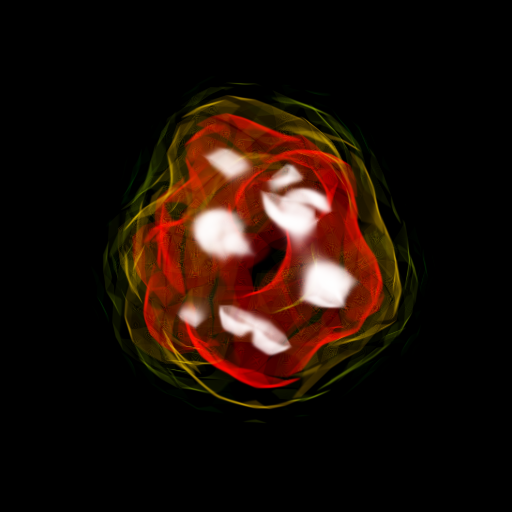

yt : [INFO     ] 2025-02-11 17:19:16,611 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:16,611 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:16,611 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:16,611 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:16,611 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:16,653 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:16,660 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:16,660 Creating volume
yt : [INFO     ] 2025-02-11 17:19:16,675 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:16,675 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


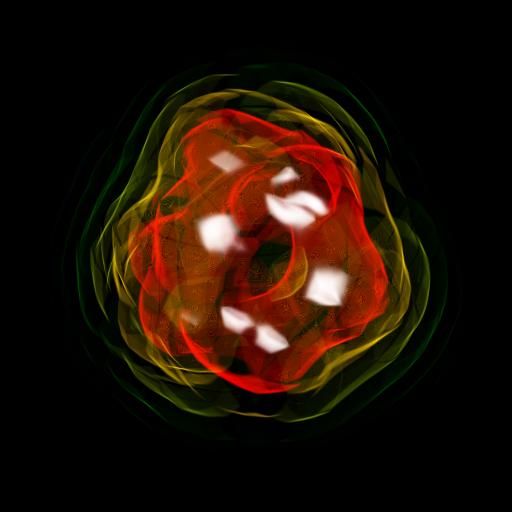

yt : [INFO     ] 2025-02-11 17:19:16,826 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:16,827 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:16,827 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:16,827 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:16,827 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:16,868 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:16,875 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:16,875 Creating volume
yt : [INFO     ] 2025-02-11 17:19:16,890 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:16,890 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


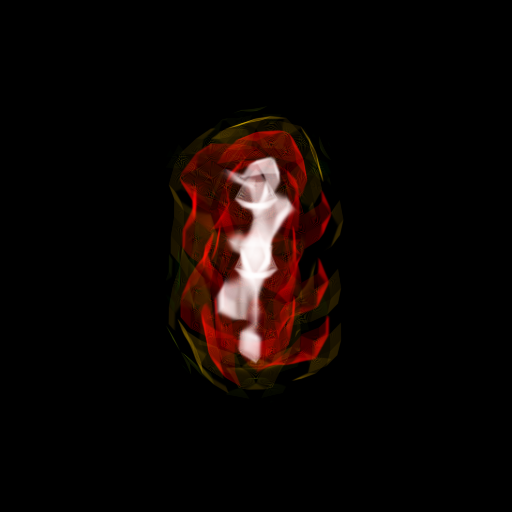

yt : [INFO     ] 2025-02-11 17:19:17,001 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:17,001 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:17,002 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:17,002 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:17,002 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:17,043 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:17,049 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:17,050 Creating volume
yt : [INFO     ] 2025-02-11 17:19:17,065 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:17,065 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


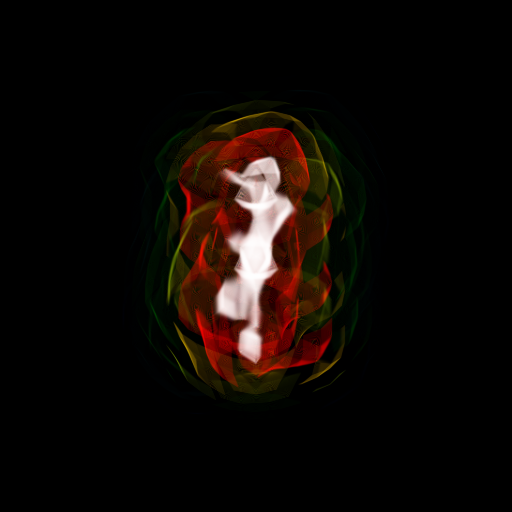

In [53]:
i = 0
for batch in dl_test:
    latent = autoencoder.encode(batch.cuda())
    reconstructed = autoencoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 0]).show()
        print("gt")
        plot_field(fd[i][:, :, :, 0]).show()
        i += 1
    break

In [54]:
def interp(arr1, arr2, num_points):
    fractions = np.linspace(0, 1, num_points)
    return np.array([arr1 + (arr2 - arr1) * f for f in fractions])

yt : [INFO     ] 2025-02-11 17:19:24,299 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:24,299 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:24,300 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:24,300 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:24,300 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:24,346 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:24,352 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:24,353 Creating volume
yt : [INFO     ] 2025-02-11 17:19:24,368 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:24,368 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


(10, 256) torch.Size([256])


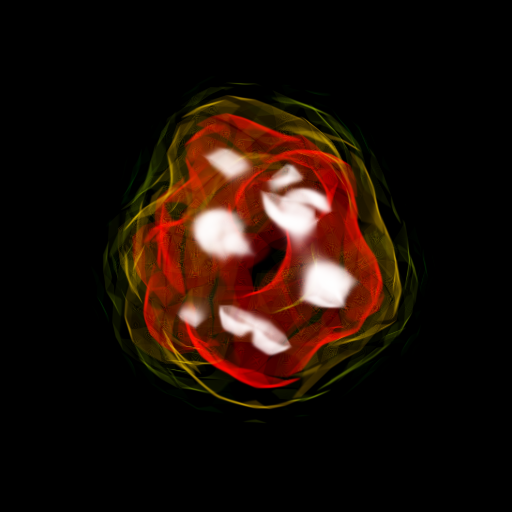

yt : [INFO     ] 2025-02-11 17:19:24,498 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:24,498 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:24,498 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:24,499 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:24,499 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:24,539 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:24,549 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:24,549 Creating volume
yt : [INFO     ] 2025-02-11 17:19:24,565 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:24,565 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


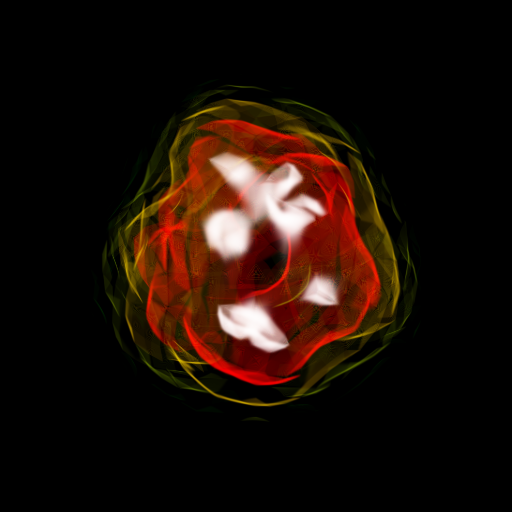

yt : [INFO     ] 2025-02-11 17:19:24,696 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:24,697 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:24,697 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:24,697 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:24,697 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:24,740 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:24,747 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:24,748 Creating volume
yt : [INFO     ] 2025-02-11 17:19:24,762 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:24,762 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


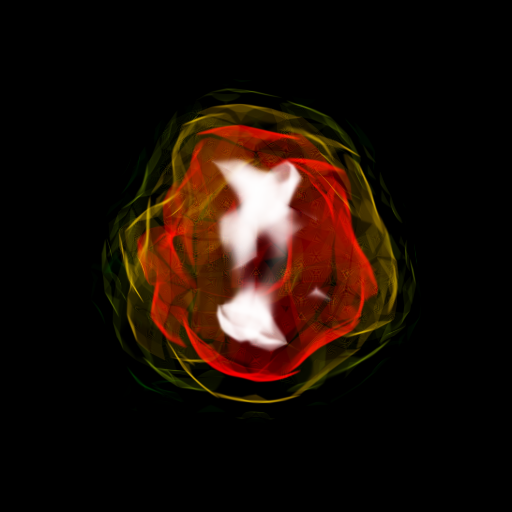

yt : [INFO     ] 2025-02-11 17:19:24,900 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:24,900 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:24,900 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:24,900 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:24,900 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:24,946 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:24,952 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:24,953 Creating volume
yt : [INFO     ] 2025-02-11 17:19:24,968 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:24,968 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


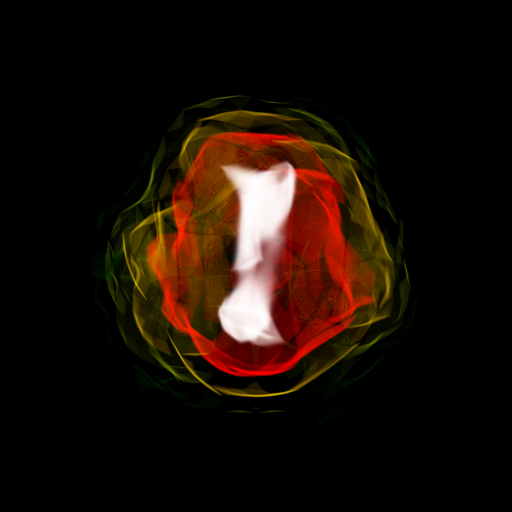

yt : [INFO     ] 2025-02-11 17:19:25,105 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:25,105 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:25,105 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:25,106 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:25,106 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:25,146 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:25,153 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:25,154 Creating volume
yt : [INFO     ] 2025-02-11 17:19:25,169 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:25,169 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


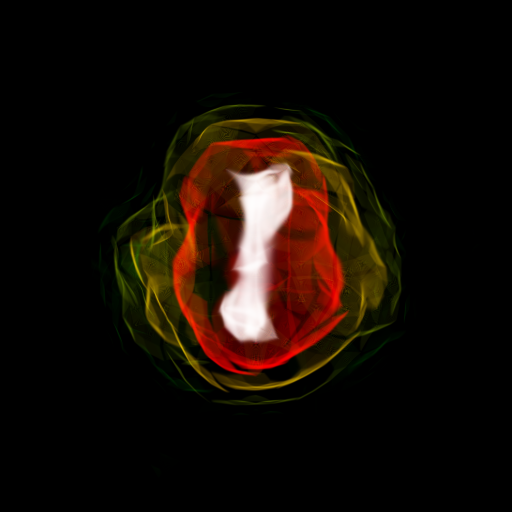

yt : [INFO     ] 2025-02-11 17:19:25,304 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:25,305 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:25,305 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:25,305 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:25,305 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:25,346 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:25,353 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:25,354 Creating volume
yt : [INFO     ] 2025-02-11 17:19:25,369 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:25,369 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


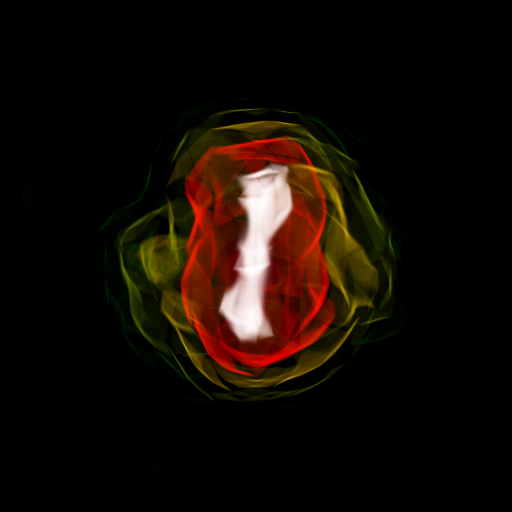

yt : [INFO     ] 2025-02-11 17:19:25,499 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:25,500 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:25,500 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:25,500 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:25,500 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:25,542 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:25,548 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:25,549 Creating volume
yt : [INFO     ] 2025-02-11 17:19:25,564 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:25,565 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


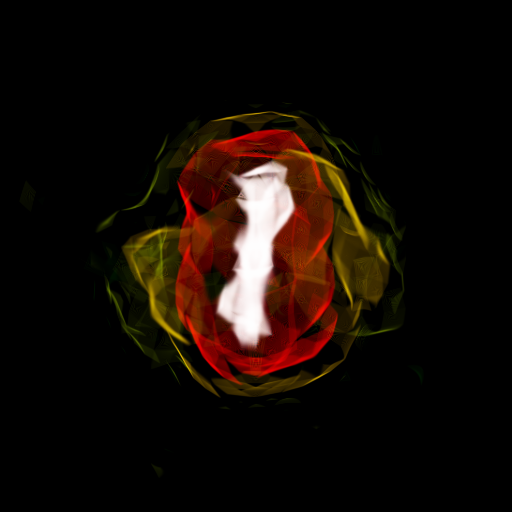

yt : [INFO     ] 2025-02-11 17:19:25,692 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:25,692 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:25,692 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:25,692 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:25,693 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:25,734 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:25,741 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:25,742 Creating volume
yt : [INFO     ] 2025-02-11 17:19:25,757 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:25,757 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


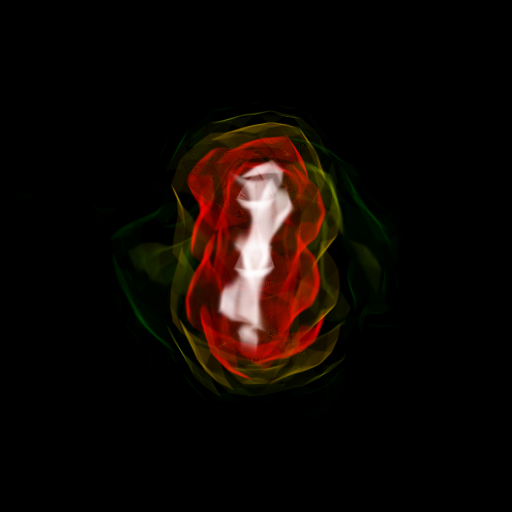

yt : [INFO     ] 2025-02-11 17:19:25,884 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:25,884 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:25,884 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:25,885 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:25,885 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:25,931 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:25,938 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:25,939 Creating volume
yt : [INFO     ] 2025-02-11 17:19:25,954 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:25,954 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


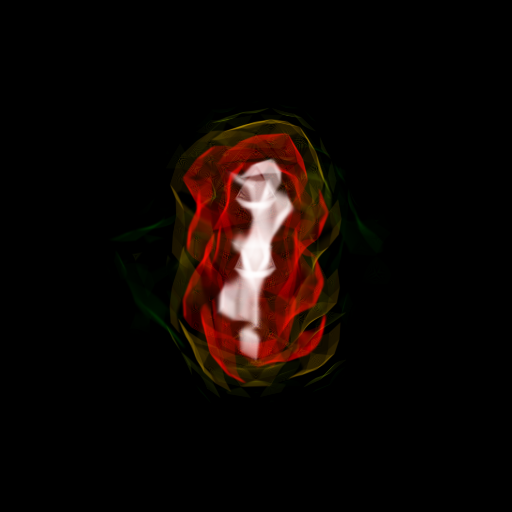

yt : [INFO     ] 2025-02-11 17:19:26,070 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 17:19:26,070 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 17:19:26,071 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 17:19:26,071 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 17:19:26,071 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 17:19:26,233 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 17:19:26,239 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 17:19:26,239 Creating volume
yt : [INFO     ] 2025-02-11 17:19:26,254 Creating transfer function
yt : [INFO     ] 2025-02-11 17:19:26,254 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


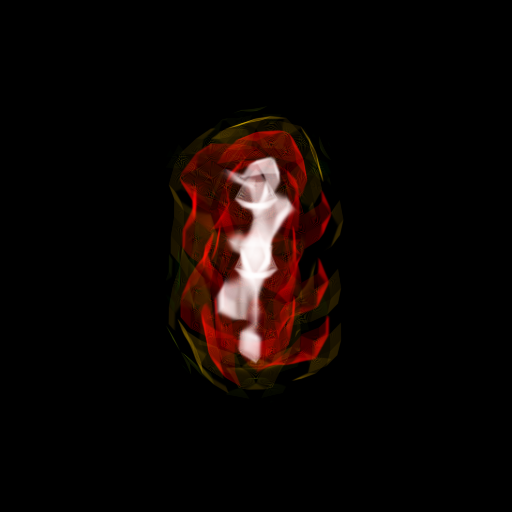

In [55]:
latents = []

for batch in dl_test:
    lats = autoencoder.encode(batch.cuda())
    for lat in lats:
        latents.append(lat.cpu().detach())

latents_intrp = interp(latents[0], latents[1], 10)
print(latents_intrp.shape, latents[0].shape)
reconstructed = autoencoder.predict(torch.FloatTensor(latents_intrp).cuda()).cpu().detach()

for r in reconstructed:
    reconstructed = reconstructed.cpu().detach().squeeze(-1)
    plot_field(r.flatten(3)[:, :, :, 0]).show()